In [ ]:
import sys, glob
from pathlib import Path
import numpy as np
import h5py
import illustris_python as il
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy.spatial import cKDTree
from PIL import Image
import sphviewer2

sys.path.insert(0, "/home2/s4636708/master_thesis_project/src")
from galaxy_sidm.mock import load_galaxy_gas

AIDA = "/scratch/s4636708/aida"
RUNS = {"CDM": f"{AIDA}/L35n1080_CDM/output",
        "SIDM1": f"{AIDA}/L35n1080_SIDM1/output",
        "vSIDM": f"{AIDA}/L35n1080_vSIDM_correa/output"}
SNAP = 67                    # z = 0.5 (the latest snapshot we have)
H_LITTLE, BOX = 0.6774, 35000.0

# --- the galaxy -----------------------------------------------------------------
CDM_SUB = 55372              # CDM subhalo; its twin in the other models is found automatically
# other good CDM discs (twin in vSIDM): 62428, 64893, 59852 (all ~1e11 Msun);
# 73647 (3e10 Msun, bigger vSIDM core, fewer stars -> softer image)

# --- what each side of the seam shows ------------------------------------------------
SIDES = {
    "left":  dict(model="CDM",   stars=True, gas=False, dm=True),
    "right": dict(model="vSIDM", stars=False, gas=True, dm=True),
}
# e.g. stars against neutral gas of the same galaxy:
#   "left": dict(model="CDM", stars=True, gas=False, dm=True), "right": dict(model="CDM", stars=False, gas=True, dm=True)

# --- layout -------------------------------------------------------------------------
WIDTH_PX, HEIGHT_PX = 2480, 3508     # A4 at 300 dpi
HEIGHT_KPC = 110.0           # physical kpc from the top to the bottom of the page
GAL_Y = 0.62                 # galaxy centre, as a fraction of the page height from the top
INCLINATION = 58             # degrees (0 = face-on)
SEAM_DEG = 65                # seam angle from horizontal, through the galaxy centre
SEAM_SOFT = 0.004            # width of the blend across the seam (fraction of the page width)
SEAM_LINE = 0.0015           # width of the dark seam line (0 = none)

# --- looks ----------------------------------------------------------------------------
STAR_Q, STAR_ALPHA = 8.0, 2.5            # Lupton asinh: lower Q = more contrast, higher alpha = brighter
STAR_BRIGHT_PCT = 99.8                   # star intensity percentile mapped to ~1
DM_TINT = {"CDM": (0.15, 0.45, 0.95), "SIDM1": (0.3, 0.4, 0.95), "vSIDM": (0.55, 0.30, 0.95)}
DM_STRENGTH, DM_GAMMA = 0.75, 2.2        # glow brightness; higher gamma = glow more concentrated to the centre
DM_PCT = (20, 99.95)                     # log-density percentiles mapped to 0 and 1
GAS_TINT = to_rgb("orangered")#(0.45, 0.85, 1.0)
GAS_STRENGTH, GAS_GAMMA = 0.85, 1.6
GAS_LOG_RANGE = (5.5, 7.8)               # log10 neutral H surface density [Msun/kpc^2] mapped to 0 and 1
                                         # (6 = 1 Msun/pc^2 = 1.25e20 cm^-2; the disc is ~7-7.5, the halo < 0)
UNDER_STARS = 0.9                        # how much the DM and gas glows fade where the stars are bright (0-1)
VIGNETTE = 0.35                          # darkening towards the page corners (0 = none)

PREVIEW = 4                  # render at 1/PREVIEW of the size for quick looks
OUT = f"/home2/s4636708/master_thesis_project/figures/cover/cover_CDM{CDM_SUB}.pdf"
THREADS = 8

In [ ]:
def scale_factor(base):
    with h5py.File(sorted(glob.glob(f"{base}/snapdir_{SNAP:03d}/snap_{SNAP:03d}.*.hdf5"))[0]) as f:
        return float(f["Header"].attrs["Time"])


def find_twin(sub, model, n_core=2000):
    """Subhalo in `model` holding most of the n_core most bound DM particles of CDM `sub`."""
    dm = il.snapshot.loadSubhalo(RUNS["CDM"], SNAP, sub, 1, fields=["ParticleIDs", "Potential"])
    core = set(dm["ParticleIDs"][np.argsort(dm["Potential"])[:n_core]].tolist())
    pos = il.groupcat.loadSingle(RUNS["CDM"], SNAP, subhaloID=sub)["SubhaloPos"]
    others = il.groupcat.loadSubhalos(RUNS[model], SNAP, fields=["SubhaloPos"])
    d = others - pos
    d -= BOX * np.round(d / BOX)
    shared = {}
    for j in np.argsort(np.linalg.norm(d, axis=1))[:5]:          # 5 nearest subhaloes
        ids = il.snapshot.loadSubhalo(RUNS[model], SNAP, int(j), 1, fields=["ParticleIDs"])
        # a subhalo without DM particles comes back as {'count': 0}
        shared[int(j)] = 0.0 if isinstance(ids, dict) else len(core & set(ids.tolist())) / n_core
    best = max(shared, key=shared.get)
    return best, shared[best]


def load_galaxy(model, sub):
    """Stars (g, r, i luminosity) and dark matter of the FoF group of `sub`, and the neutral gas
    bound to `sub`, all in physical kpc around it."""
    base = RUNS[model]
    a = scale_factor(base)
    s = il.groupcat.loadSingle(base, SNAP, subhaloID=sub)
    st = il.snapshot.loadHalo(base, SNAP, s["SubhaloGrNr"], 4, fields=["Coordinates", "Velocities",
                              "GFM_StellarPhotometrics", "GFM_StellarFormationTime"])
    dm = il.snapshot.loadHalo(base, SNAP, s["SubhaloGrNr"], 1, fields=["Coordinates", "SubfindHsml"])
    real = st["GFM_StellarFormationTime"] > 0                     # drop wind particles

    def rel(x):
        d = x - s["SubhaloPos"]
        d -= BOX * np.round(d / BOX)
        return d * a / H_LITTLE

    xs = rel(st["Coordinates"][real])
    gas = load_galaxy_gas(base, SNAP, sub, h=H_LITTLE)            # same loader as the mock HI cubes
    return dict(xs=xs, vs=st["Velocities"][real] * np.sqrt(a) - s["SubhaloVel"],
                gri=10 ** (-0.4 * st["GFM_StellarPhotometrics"][real][:, 4:7]),   # g, r, i abs. AB mag -> luminosity
                hs=np.maximum(cKDTree(xs).query(xs, k=25)[0][:, -1], 0.05),        # 24th stellar neighbour
                xd=rel(dm["Coordinates"]), hd=dm["SubfindHsml"] * a / H_LITTLE,
                xg=gas.xyz_g.to_value("kpc"), hg=gas.hsm_g.to_value("kpc"), mg=gas.mH_neutral_g.to_value("Msun"))


def view_rotation(gal, incl_deg, r_in=10.0):
    """World -> image frame: stellar spin (r < r_in, r-band weighted) along the line of sight, then inclined."""
    inner = np.linalg.norm(gal["xs"], axis=1) < r_in
    L = (gal["gri"][inner, 1][:, None] * np.cross(gal["xs"][inner], gal["vs"][inner])).sum(0)
    L /= np.linalg.norm(L)
    t = np.array([1.0, 0, 0]) if abs(L[0]) < 0.9 else np.array([0, 1.0, 0])
    e1 = np.cross(t, L); e1 /= np.linalg.norm(e1)
    R = np.vstack([e1, np.cross(L, e1), L])
    i = np.radians(incl_deg)
    return np.array([[1, 0, 0], [0, np.cos(i), -np.sin(i)], [0, np.sin(i), np.cos(i)]]) @ R


def render_page(gal, width_px, height_px):
    """Maps on the page grid (row 0 = bottom), per kpc^2: stellar g, r, i luminosity, DM particles, neutral H mass."""
    R = view_rotation(gal, INCLINATION)
    px = HEIGHT_KPC / height_px
    n = 2 ** int(np.ceil(np.log2(max(width_px, height_px))))     # square render window, power of 2
    size, yc = n * px, (GAL_Y - 0.5) * HEIGHT_KPC                # window centred on the page centre

    def one(x, h, m):
        x = x @ R.T
        keep = (np.abs(x[:, 0]) < 0.75 * size) & (np.abs(x[:, 1] - yc) < 0.75 * size)
        # sphviewer2: `extent` is the full width of the image; the output is already per unit area
        out = sphviewer2.render(x[keep, 0], x[keep, 1], x[keep, 2], h[keep], m[keep], 2 * size, extent=size,
                                xc=0.0, yc=yc, zc=0.0, periodic=False, r_max=int(np.log2(n)),
                                target_cells_per_h=4, num_threads=THREADS)
        img = np.asarray(out[0] if isinstance(out, (tuple, list)) else out, float)
        y0, x0 = (n - height_px) // 2, (n - width_px) // 2
        return img[y0:y0 + height_px, x0:x0 + width_px]

    maps = {band: one(gal["xs"], gal["hs"], gal["gri"][:, k]) for k, band in enumerate("gri")}
    maps["dm"] = one(gal["xd"], gal["hd"], np.ones(len(gal["xd"])))
    maps["gas"] = one(gal["xg"], gal["hg"], gal["mg"])
    return maps

In [ ]:
def lupton_gri(g, r, i, scale):
    """temet's gri recipe (Lupton+2004): RGB = (0.8 i, r, g), asinh-stretched intensity."""
    g, r, i = g * scale, r * scale, 0.8 * i * scale
    inten = (g + r + i) / 3
    f = np.arcsinh(STAR_ALPHA * STAR_Q * inten) / STAR_Q / np.where(inten > 0, inten, 1)
    return np.clip(np.dstack([i * f, r * f, g * f]), 0, 1)


def log_range(sigma, pct):
    return np.percentile(np.log10(sigma[sigma > 0]), pct)


def glow(sigma, vrange, gamma, strength, tint):
    vmin, vmax = vrange
    lg = np.log10(np.where(sigma > 0, sigma, 10.0 ** vmin))
    t = np.clip((lg - vmin) / (vmax - vmin), 0, 1) ** gamma
    return strength * t[..., None] * np.asarray(tint)[None, None, :]


def screen(a, b):
    return 1 - (1 - a) * (1 - b)


def compose(maps, width_px, height_px):
    """Both sides with the same stretches (set by the CDM maps), joined along the seam."""
    ref = maps["CDM"]
    star_scale = 1 / np.percentile((ref["g"] + ref["r"] + ref["i"]) / 3, STAR_BRIGHT_PCT)
    dm_range, gas_range = log_range(ref["dm"], DM_PCT), GAS_LOG_RANGE
    layer = {}
    for side, show in SIDES.items():
        m = maps[show["model"]]
        img = np.zeros((height_px, width_px, 3))
        stars = lupton_gri(m["g"], m["r"], m["i"], star_scale) if show["stars"] else None
        fade = (1 - UNDER_STARS * stars.max(axis=2))[..., None] if show["stars"] else 1.0
        if show["dm"]:
            img = screen(img, fade * glow(m["dm"], dm_range, DM_GAMMA, DM_STRENGTH, DM_TINT[show["model"]]))
        if show["gas"]:
            img = screen(img, fade * glow(m["gas"], gas_range, GAS_GAMMA, GAS_STRENGTH, GAS_TINT))
        if show["stars"]:
            img = screen(img, stars)                                    # stars on top
        layer[side] = img
    yy, xx = np.mgrid[0:height_px, 0:width_px]
    gx, gy = width_px / 2, (1 - GAL_Y) * height_px                      # galaxy centre (row 0 = bottom)
    t = np.radians(SEAM_DEG)
    s = ((xx - gx) * np.sin(t) - (yy - gy) * np.cos(t)) / width_px      # signed distance from the seam
    w = 1 / (1 + np.exp(-s / SEAM_SOFT))[..., None]                     # 0 left of the seam, 1 right
    img = (1 - w) * layer["left"] + w * layer["right"]
    if SEAM_LINE > 0:
        img *= (1 - 0.6 * np.exp(-(s / SEAM_LINE) ** 2))[..., None]
    if VIGNETTE > 0:
        rr = np.hypot((xx - width_px / 2) / width_px, (yy - height_px / 2) / height_px)
        img *= (1 - VIGNETTE * np.clip(rr / 0.7, 0, 1) ** 2)[..., None]
    return np.clip(img[::-1], 0, 1)                                     # row 0 = top, for saving/showing


_maps_cache = {}

def page_maps(width_px, height_px):
    """Maps of every model in use at this size; a model is re-rendered only when the view changes."""
    view = (CDM_SUB, HEIGHT_KPC, GAL_Y, INCLINATION, width_px, height_px)
    for key in [k for k in _maps_cache if k[0][-2:] == (width_px, height_px) and k[0] != view]:
        del _maps_cache[key]                                    # drop maps of an older view at this size
    for m, g in gals.items():
        if (view, m) not in _maps_cache:
            _maps_cache[(view, m)] = render_page(g, width_px, height_px)
    return {m: _maps_cache[(view, m)] for m in gals}

In [ ]:
# find the twins and load the galaxies; each (CDM_SUB, model) is loaded once and kept
models = {"CDM"} | {s["model"] for s in SIDES.values()}          # CDM always: it sets the stretches
_gal_cache = globals().setdefault("_gal_cache", {})
for m in sorted(models):
    if (CDM_SUB, m) not in _gal_cache:
        sub = CDM_SUB
        if m != "CDM":
            sub, shared = find_twin(CDM_SUB, m)
            print(f"CDM {CDM_SUB} -> {m} {sub}: {shared:.0%} of the CDM core DM particles shared")
        _gal_cache[(CDM_SUB, m)] = load_galaxy(m, sub)
gals = {m: _gal_cache[(CDM_SUB, m)] for m in sorted(models)}
for m, g in gals.items():
    print(f"{m}: {len(g['xs'])} stars, {len(g['xg'])} gas cells, {len(g['xd'])} DM particles")

CDM 55372 -> vSIDM 52814: 100% of the CDM core DM particles shared
CDM: 220498 stars, 318981 gas cells, 650745 DM particles
vSIDM: 220441 stars, 309978 gas cells, 653932 DM particles


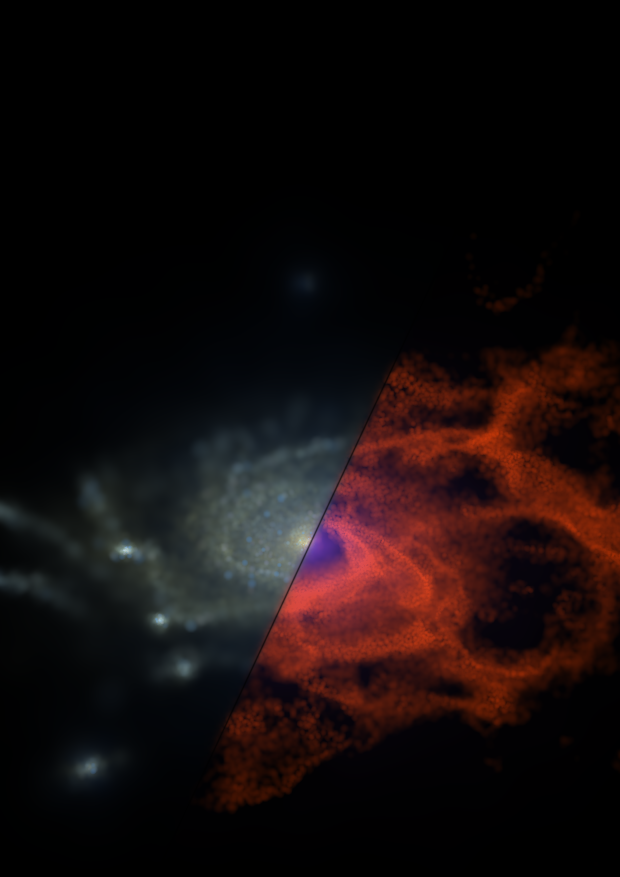

In [ ]:
GAS_TINT = to_rgb("orangered")#cornflowerblue
# quick preview at 1/PREVIEW of the size
w, h = WIDTH_PX // PREVIEW, HEIGHT_PX // PREVIEW
preview = compose(page_maps(w, h), w, h)
from IPython.display import display
display(Image.fromarray((preview * 255).round().astype(np.uint8)))

In [ ]:
# full size (2480 x 3508 px), saved as PNG with 300 dpi metadata
cover = compose(page_maps(WIDTH_PX, HEIGHT_PX), WIDTH_PX, HEIGHT_PX)
Path(OUT).parent.mkdir(parents=True, exist_ok=True)
Image.fromarray((cover * 255).round().astype(np.uint8)).save(OUT, dpi=(300, 300))
print("saved", OUT)

saved /home2/s4636708/master_thesis_project/figures/cover/cover_CDM55372.pdf


: 

In [ ]:
for m in ("SIDM1", "vSIDM"):
    twin, shared = find_twin(CDM_SUB, m)
    print(f"CDM {CDM_SUB} -> {m} subID {twin} ({shared:.0%} of the CDM core DM particles shared)")

CDM 55372 -> SIDM1 subID 54545 (99% of the CDM core DM particles shared)
CDM 55372 -> vSIDM subID 52814 (100% of the CDM core DM particles shared)
